<a href="https://colab.research.google.com/github/anilkumargangadhara09/GenAI-ML/blob/main/SyntheticData_ML_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Here's an example of training a simple machine learning model (Linear Regression) using scikit-learn. I'll include steps for data generation, splitting, training, prediction, and evaluation.

The machine learning model training demonstration is complete! Here's a summary of what happened:

Synthetic Data Generation: We successfully created and visualized synthetic data that follows a linear trend, which was then split into training and testing sets.
Model Training: A Linear Regression model was trained on the data. The model found an intercept of 4.43 and a coefficient (slope) of 2.73, which are close to the 4 + 3X relationship we defined when generating the data.
Predictions: The model made predictions on the unseen test data, and the plot showed how well the predicted line fits the actual test data points.
Evaluation: The model's performance was evaluated using:
Mean Squared Error (MSE): 1.06 - This indicates the average squared difference between the estimated values and the actual value. Lower values are better.
R-squared (R2 Score): 0.77 - This represents the proportion of variance in the dependent variable that can be predicted from the independent variable(s). An R2 score of 0.77 means that 77% of the variance in the target variable can be explained by our model, which is a reasonably good fit for this synthetic data.
This example successfully demonstrates the full workflow of training and evaluating a simple machine learning model.

### 1. Generate Synthetic Data

First, let's create some simple synthetic data to work with. We'll generate data that roughly follows a linear relationship with some added noise.

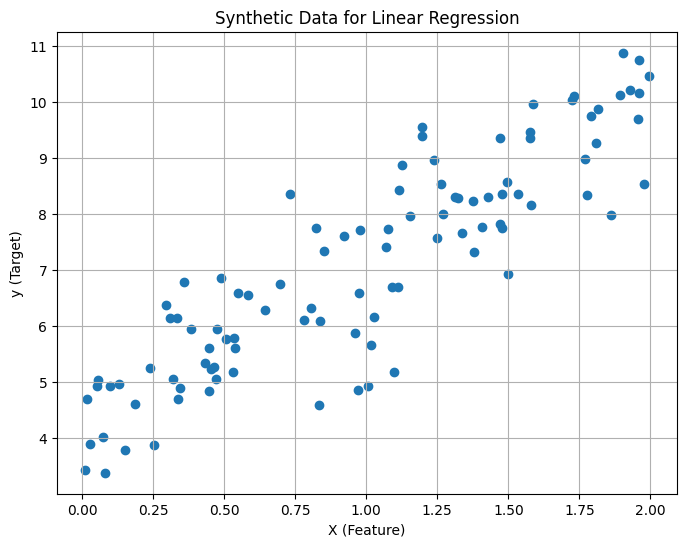

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic data
X = 2 * np.random.rand(100, 1) # 100 samples, 1 feature
y = 4 + 3 * X + np.random.randn(100, 1) # y = 4 + 3X + noise

plt.figure(figsize=(8, 6))
plt.scatter(X, y)
plt.xlabel("X (Feature)")
plt.ylabel("y (Target)")
plt.title("Synthetic Data for Linear Regression")
plt.grid(True)
plt.show()

### 2. Split Data into Training and Testing Sets

It's crucial to split our data into training and testing sets. The model will learn from the training data and then be evaluated on the unseen testing data to assess its generalization performance.

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}, {y_train.shape}")
print(f"Testing data shape: {X_test.shape}, {y_test.shape}")

Training data shape: (80, 1), (80, 1)
Testing data shape: (20, 1), (20, 1)


### 3. Train a Simple Linear Regression Model

We'll use scikit-learn's `LinearRegression` model. This model finds the best-fitting straight line through the data points.

In [3]:
from sklearn.linear_model import LinearRegression

# Create a Linear Regression model instance
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

print(f"Model Intercept: {model.intercept_[0]:.2f}")
print(f"Model Coefficient (slope): {model.coef_[0][0]:.2f}")

Model Intercept: 4.43
Model Coefficient (slope): 2.73


### 4. Make Predictions

Now that the model is trained, we can use it to make predictions on our test set.

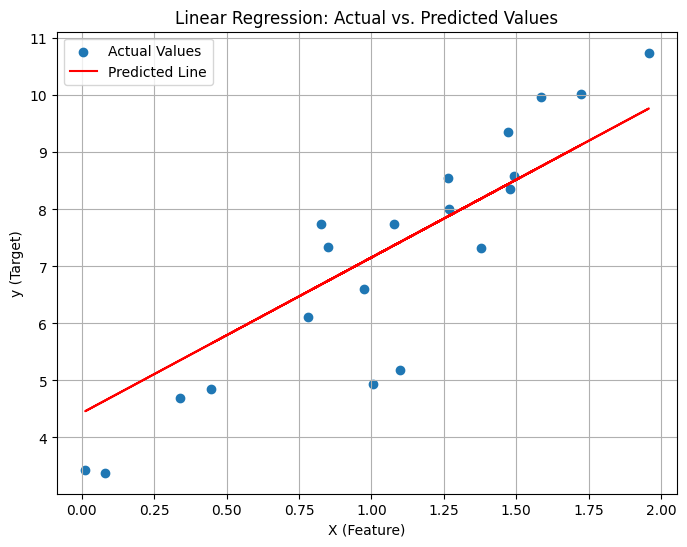

In [4]:
y_pred = model.predict(X_test)

# Plot the predictions against the actual values
plt.figure(figsize=(8, 6))
plt.scatter(X_test, y_test, label='Actual Values')
plt.plot(X_test, y_pred, color='red', label='Predicted Line')
plt.xlabel("X (Feature)")
plt.ylabel("y (Target)")
plt.title("Linear Regression: Actual vs. Predicted Values")
plt.legend()
plt.grid(True)
plt.show()

### 5. Evaluate the Model

To understand how well our model performed, we can use various evaluation metrics. For regression, common metrics include Mean Squared Error (MSE) and R-squared ($R^2$).

In [5]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2 Score): {r2:.2f}")

Mean Squared Error (MSE): 1.06
R-squared (R2 Score): 0.77


### How to Improve Model Accuracy

Improving model accuracy is a crucial aspect of machine learning. Here are common strategies:

1.  **More Data:** Often, providing more diverse and representative training data can significantly improve a model's ability to generalize.
2.  **Feature Engineering:** Create new features or transform existing ones to better represent the underlying patterns in the data.
3.  **Feature Selection:** Remove irrelevant or redundant features to improve accuracy and reduce overfitting.
4.  **Try Different Models:** Experiment with other models (e.g., Decision Trees, Random Forests, Support Vector Machines, Gradient Boosting Machines) that might be better suited for the data and capture more complex relationships.
5.  **Hyperparameter Tuning:** Optimize model hyperparameters (settings not learned from data) using techniques like `GridSearchCV` or `RandomizedSearchCV`.
6.  **Regularization:** Apply techniques like L1 (Lasso) or L2 (Ridge) regularization to prevent overfitting by penalizing large coefficients.
7.  **Handle Outliers and Missing Values:** Properly address outliers and missing data to prevent them from negatively impacting model training.
8.  **Ensemble Methods:** Combine multiple models (e.g., Bagging, Boosting) to often yield better predictions than a single model.

For this specific linear regression model, given its synthetic nature, improvements would primarily involve:
*   **Reducing noise:** A smaller random noise component would lead to a better fit.
*   **More data:** While 100 samples are used, a larger dataset could help if the underlying linear relationship were more complex.
*   **Checking for linearity:** If the true relationship between X and y were non-linear, a different model type would be necessary.

### Using GridSearchCV for Hyperparameter Tuning

`GridSearchCV` exhaustively searches over specified parameter values for an estimator. For each combination of parameters, it trains a model and evaluates its performance using cross-validation. This allows us to find the best set of hyperparameters that result in the best model performance.

Since our basic `LinearRegression` has very few hyperparameters to tune in a meaningful way for this synthetic dataset, let's switch to `Ridge` Regression. `Ridge` Regression is a linear model that uses L2 regularization, meaning it adds a penalty to the loss function that is proportional to the square of the magnitude of the coefficients. This helps prevent overfitting, and its strength is controlled by the `alpha` hyperparameter.

In [6]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Define the model (Ridge Regression in this case)
ridge_model = Ridge()

# Define the parameter grid to search over
# We'll tune the 'alpha' hyperparameter for Ridge Regression
param_grid = {
    'alpha': [0.1, 1.0, 10.0, 100.0]
}

# Initialize GridSearchCV
# estimator: The model to tune
# param_grid: The dictionary of hyperparameters and their values to search
# cv: Number of folds for cross-validation
# scoring: Metric to evaluate models (e.g., 'neg_mean_squared_error' for MSE, 'r2' for R-squared)
grid_search = GridSearchCV(
    estimator=ridge_model,
    param_grid=param_grid,
    cv=5, # 5-fold cross-validation
    scoring='neg_mean_squared_error', # Using negative MSE, GridSearchCV tries to maximize the score
    verbose=1, # Prints progress
    n_jobs=-1 # Use all available CPU cores
)

# Fit GridSearchCV to the training data
# This will perform cross-validation for each combination of hyperparameters
grid_search.fit(X_train, y_train)

# Print the best hyperparameters found
print(f"Best hyperparameters: {grid_search.best_params_}")

# Print the best cross-validation score (remember it's negative MSE)
# To get positive MSE, multiply by -1
print(f"Best cross-validation MSE: {-grid_search.best_score_:.2f}")

# Get the best model
best_ridge_model = grid_search.best_estimator_

# Make predictions with the best model on the test set
y_pred_tuned = best_ridge_model.predict(X_test)

# Evaluate the best model on the test set
mse_tuned = mean_squared_error(y_test, y_pred_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

print(f"\nTest set Mean Squared Error with best Ridge model: {mse_tuned:.2f}")
print(f"Test set R-squared with best Ridge model: {r2_tuned:.2f}")

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best hyperparameters: {'alpha': 0.1}
Best cross-validation MSE: 0.76

Test set Mean Squared Error with best Ridge model: 1.06
Test set R-squared with best Ridge model: 0.77


### Tuning Random Forest Hyperparameters with GridSearchCV

Now, let's apply `GridSearchCV` to a more complex model like `RandomForestRegressor`. Random Forests often perform very well, but their performance can be sensitive to their hyperparameters. We'll search for the best combination of parameters like the number of trees (`n_estimators`), the maximum depth of each tree (`max_depth`), and the minimum number of samples required to be at a leaf node (`min_samples_leaf`).

In [7]:
from sklearn.ensemble import RandomForestRegressor

# Define the Random Forest Regressor model
rf_model = RandomForestRegressor(random_state=42)

# Define the parameter grid to search over for RandomForestRegressor
# Note: This is an example, for real-world scenarios, you might expand or refine this grid.
param_grid_rf = {
    'n_estimators': [50, 100, 200], # Number of trees in the forest
    'max_depth': [None, 10, 20], # Maximum depth of the tree
    'min_samples_leaf': [1, 5, 10] # Minimum number of samples required to be at a leaf node
}

# Initialize GridSearchCV for Random Forest
grid_search_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid_rf,
    cv=5, # 5-fold cross-validation
    scoring='neg_mean_squared_error', # Maximize negative MSE (minimize MSE)
    verbose=1, # Prints progress
    n_jobs=-1 # Use all available CPU cores
)

# Fit GridSearchCV to the training data
grid_search_rf.fit(X_train, y_train.ravel()) # .ravel() to convert y_train to 1D array

# Print the best hyperparameters found
print(f"\nBest Random Forest hyperparameters: {grid_search_rf.best_params_}")

# Print the best cross-validation score
print(f"Best Random Forest cross-validation MSE: {-grid_search_rf.best_score_:.2f}")

# Get the best Random Forest model
best_rf_model = grid_search_rf.best_estimator_

# Make predictions with the best Random Forest model on the test set
y_pred_rf = best_rf_model.predict(X_test)

# Evaluate the best Random Forest model on the test set
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"\nTest set Mean Squared Error with best Random Forest model: {mse_rf:.2f}")
print(f"Test set R-squared with best Random Forest model: {r2_rf:.2f}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits

Best Random Forest hyperparameters: {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 200}
Best Random Forest cross-validation MSE: 0.71

Test set Mean Squared Error with best Random Forest model: 0.98
Test set R-squared with best Random Forest model: 0.78


### Visualize Random Forest Model Predictions

Let's plot the actual values from the test set against the predictions made by our best Random Forest model. This visualization helps us qualitatively assess the model's fit.

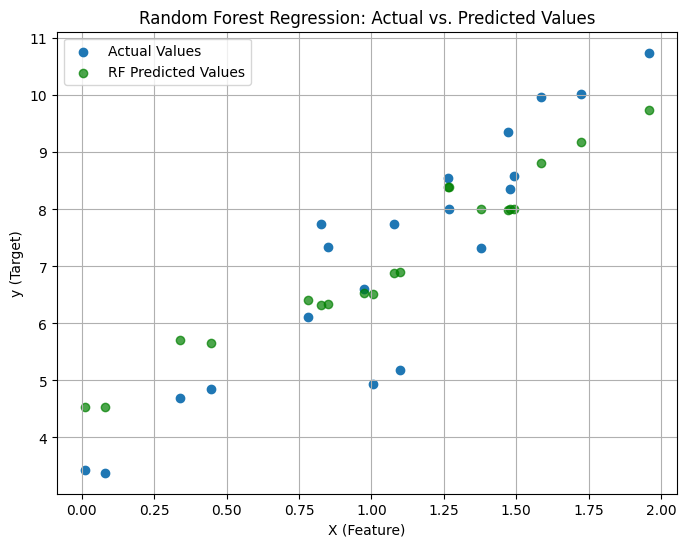

In [8]:
import matplotlib.pyplot as plt

# Plot the actual values vs. predicted values for the Random Forest model
plt.figure(figsize=(8, 6))
plt.scatter(X_test, y_test, label='Actual Values')
plt.scatter(X_test, y_pred_rf, color='green', alpha=0.7, label='RF Predicted Values')
plt.xlabel("X (Feature)")
plt.ylabel("y (Target)")
plt.title("Random Forest Regression: Actual vs. Predicted Values")
plt.legend()
plt.grid(True)
plt.show()

### Visualize Random Forest Model Residuals

Residuals (the difference between actual and predicted values) are important for understanding the errors your model makes. A good model should have residuals randomly distributed around zero, with no clear patterns.

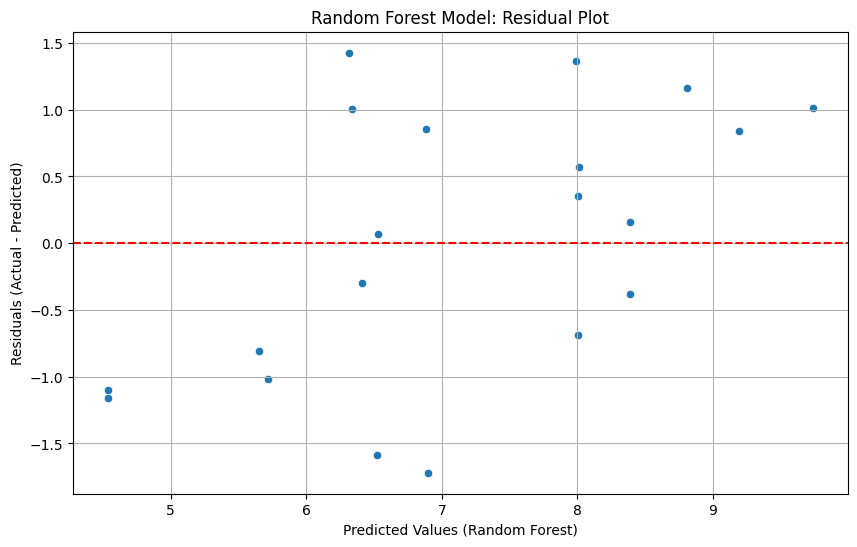

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate residuals
residuals_rf = y_test.flatten() - y_pred_rf.flatten()

# Plotting residuals against predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_rf.flatten(), y=residuals_rf)
plt.axhline(y=0, color='r', linestyle='--') # Add a horizontal line at y=0
plt.xlabel("Predicted Values (Random Forest)")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Random Forest Model: Residual Plot")
plt.grid(True)
plt.show()

### Tuning Gradient Boosting Model with GridSearchCV

Gradient Boosting is another powerful ensemble technique that builds models sequentially, where each new model corrects errors made by previous ones. Like Random Forests, it has several hyperparameters that can significantly impact performance, so `GridSearchCV` is useful here.

In [10]:
from sklearn.ensemble import GradientBoostingRegressor

# Define the Gradient Boosting Regressor model
gbr_model = GradientBoostingRegressor(random_state=42)

# Define the parameter grid to search over for GradientBoostingRegressor
# This is an example, you might expand or refine this grid for real-world tasks.
param_grid_gbr = {
    'n_estimators': [50, 100, 200], # Number of boosting stages
    'learning_rate': [0.01, 0.1, 0.2], # Shrinks the contribution of each tree
    'max_depth': [3, 5, 7] # Maximum depth of the individual regression estimators
}

# Initialize GridSearchCV for Gradient Boosting
grid_search_gbr = GridSearchCV(
    estimator=gbr_model,
    param_grid=param_grid_gbr,
    cv=5, # 5-fold cross-validation
    scoring='neg_mean_squared_error', # Maximize negative MSE (minimize MSE)
    verbose=1, # Prints progress
    n_jobs=-1 # Use all available CPU cores
)

# Fit GridSearchCV to the training data
grid_search_gbr.fit(X_train, y_train.ravel()) # .ravel() to convert y_train to 1D array

# Print the best hyperparameters found
print(f"\nBest Gradient Boosting hyperparameters: {grid_search_gbr.best_params_}")

# Print the best cross-validation score
print(f"Best Gradient Boosting cross-validation MSE: {-grid_search_gbr.best_score_:.2f}")

# Get the best Gradient Boosting model
best_gbr_model = grid_search_gbr.best_estimator_

# Make predictions with the best Gradient Boosting model on the test set
y_pred_gbr = best_gbr_model.predict(X_test)

# Evaluate the best Gradient Boosting model on the test set
mse_gbr = mean_squared_error(y_test, y_pred_gbr)
r2_gbr = r2_score(y_test, y_pred_gbr)

print(f"\nTest set Mean Squared Error with best Gradient Boosting model: {mse_gbr:.2f}")
print(f"Test set R-squared with best Gradient Boosting model: {r2_gbr:.2f}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits

Best Gradient Boosting hyperparameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}
Best Gradient Boosting cross-validation MSE: 0.80

Test set Mean Squared Error with best Gradient Boosting model: 1.21
Test set R-squared with best Gradient Boosting model: 0.73
